<a href="https://colab.research.google.com/github/mauriciobrito31-ui/BA320HW/blob/main/MBQ3_2_1_Linear_Multiple_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.8 MB/s eta 0:00:00


In [2]:
import pymysql
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Create a direct connection to the database
conn = pymysql.connect(
    host='database-klee.cbgcswckszgl.us-east-1.rds.amazonaws.com',
    user='erau',
    password='1212',
    database='airline_db',
    charset='utf8mb4'
)

# Query data from the flights_delay table
query = """
SELECT
    flight_id,
    departure_delay_mins,
    delay_minutes AS arrival_delay_mins,
    weather_condition,
    day_of_week,
    aircraft_type,
    airline_code
FROM
    flights_delay
WHERE
    departure_delay_mins IS NOT NULL
    AND delay_minutes IS NOT NULL
    AND weather_condition IS NOT NULL;
"""

# Execute the query and load data into a DataFrame
df = pd.read_sql_query(query, conn)

# Close the database connection
conn.close()
# print("Database connection closed.")
# print(f"Data loaded successfully. Total records: {len(df)}")
# print("\nData types:")
# print(df.dtypes)
# print("\nFirst 5 rows:")
# print(df.head())

In [4]:
df.head()

,flight_id,departure_delay_mins,arrival_delay_mins,weather_condition,day_of_week,aircraft_type,airline_code
0,1,6,22,Clear,Saturday,A330-300,DL
1,2,20,62,Snow,Sunday,A330-300,OZ
2,3,12,28,Rain,Monday,A350-900,EK
3,4,8,15,Cloudy,Monday,A350-900,NH
4,5,15,27,Clear,Monday,B787-9,OZ


In [5]:
# Check for missing values before cleaning
print("Missing values per column:")
print(df.isnull().sum())

# Only drop rows with missing values in critical columns
df_cleaned = df.dropna(subset=['departure_delay_mins', 'arrival_delay_mins', 'weather_condition'])

print(f"\nOriginal data: {len(df)} records")
print(f"Cleaned data: {len(df_cleaned)} records")
print(f"Removed records: {len(df) - len(df_cleaned)}")
print("Shape of the final dataset:", df_cleaned.shape)

# Use cleaned dataset for further analysis
df_cleaned

Missing values per column:
flight_id               0
departure_delay_mins    0
arrival_delay_mins      0
weather_condition       0
day_of_week             0
aircraft_type           0
airline_code            0
dtype: int64

Original data: 500 records
Cleaned data: 500 records
Removed records: 0
Shape of the final dataset: (500, 7)


,flight_id,departure_delay_mins,arrival_delay_mins,weather_condition,day_of_week,aircraft_type,airline_code
0,1,6,22,Clear,Saturday,A330-300,DL
1,2,20,62,Snow,Sunday,A330-300,OZ
2,3,12,28,Rain,Monday,A350-900,EK
3,4,8,15,Cloudy,Monday,A350-900,NH
4,5,15,27,Clear,Monday,B787-9,OZ
...,...,...,...,...,...,...,...
495,496,4,1,Clear,Thursday,B787-9,LH
496,497,0,0,Cloudy,Friday,B787-9,SQ
497,498,9,15,Clear,Tuesday,A380-800,OZ
498,499,29,60,Thunderstorm,Wednesday,B737-MAX,JL


In [8]:
# Build the multiple regression model
model = smf.ols("arrival_delay_mins ~ departure_delay_mins + C(weather_condition, Treatment(reference='Clear'))", data=df_cleaned).fit()



In [7]:
# Print the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     arrival_delay_mins   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     668.0
Date:                Sat, 27 Sep 2025   Prob (F-statistic):          4.26e-233
Time:                        17:15:50   Log-Likelihood:                -1787.4
No. Observations:                 500   AIC:                             3589.
Df Residuals:                     493   BIC:                             3618.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

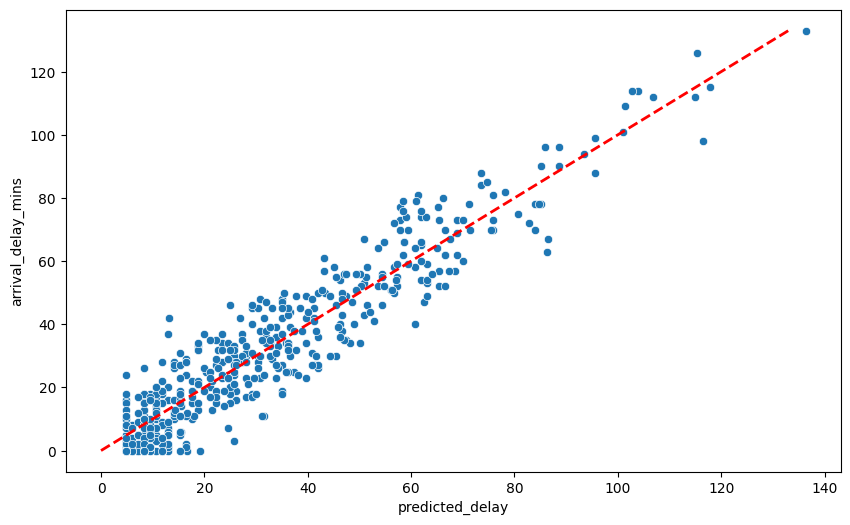

In [11]:
df_cleaned['predicted_delay'] = model.fittedvalues

plt.figure(figsize=(10, 6))
sns.scatterplot(x='predicted_delay', y='arrival_delay_mins', data=df_cleaned)
plt.plot([df_cleaned['arrival_delay_mins'].min(), df_cleaned['arrival_delay_mins'].max()],
         [df_cleaned['arrival_delay_mins'].min(), df_cleaned['arrival_delay_mins'].max()],'r--', lw=2)

Text(0, 0.5, 'Average Arrival Delay (minutes)')

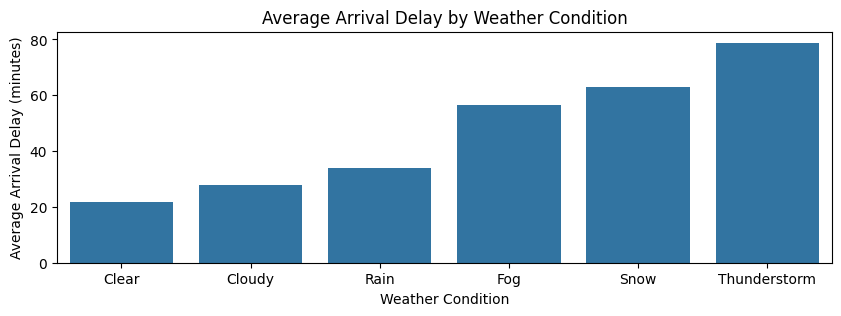

In [12]:
plt.figure(figsize=(10, 3))
weather_means = df_cleaned.groupby('weather_condition')['arrival_delay_mins'].mean().sort_values()
sns.barplot(x=weather_means.index, y=weather_means.values)
plt.title('Average Arrival Delay by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Arrival Delay (minutes)')

In [13]:
df_cleaned.groupby('weather_condition')['arrival_delay_mins'].describe()

,count,mean,std,min,25%,50%,75%,max
weather_condition,,,,,,,,
Clear,223.0,21.695067,23.563912,0.0,4.5,16.0,30.50,133.0
Cloudy,123.0,27.894309,21.812094,0.0,12.5,25.0,37.00,99.0
Fog,43.0,56.604651,23.216517,11.0,41.5,55.0,71.00,112.0
Rain,71.0,33.957746,17.072481,0.0,22.5,32.0,44.00,79.0
Snow,28.0,62.964286,12.200432,40.0,52.0,62.0,72.25,90.0
Thunderstorm,12.0,78.833333,24.964824,51.0,58.5,73.0,99.00,115.0
